# Unemployment Analysis with Python
CodeAlpha Data Science Internship

This notebook analyzes unemployment rate trends across Indian states during 2020, with a focus on the impact of Covid-19.

## 1. Load and Explore the Dataset

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/unemployment.csv')

# Clean up column names (dataset has leading/trailing spaces and a duplicate Region column)
df.columns = df.columns.str.strip()
df = df.loc[:, ~df.columns.duplicated()]
df.columns = ['Region', 'Date', 'Frequency', 'Unemployment_Rate', 'Employed', 'Labour_Participation_Rate', 'Area', 'Longitude', 'Latitude']

df.head()

,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Area,Longitude,Latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [2]:
df.info()
print()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Region                     267 non-null    str    
 1   Date                       267 non-null    str    
 2   Frequency                  267 non-null    str    
 3   Unemployment_Rate          267 non-null    float64
 4   Employed                   267 non-null    int64  
 5   Labour_Participation_Rate  267 non-null    float64
 6   Area                       267 non-null    str    
 7   Longitude                  267 non-null    float64
 8   Latitude                   267 non-null    float64
dtypes: float64(4), int64(1), str(4)
memory usage: 18.9 KB



,Unemployment_Rate,Employed,Labour_Participation_Rate,Longitude,Latitude
count,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,12.236929,1.396211e+07,41.681573,22.826048,80.532425
std,10.803283,1.336632e+07,7.845419,6.270731,5.831738
min,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,75.850000,5.943376e+07,69.690000,33.778200,92.937600


In [3]:
print("Missing values:\n", df.isnull().sum())
print("\nRegions covered:", df['Region'].nunique())
print("Date range:", df['Date'].str.strip().min(), "to", df['Date'].str.strip().max())

Missing values:
 Region                       0
Date                         0
Frequency                    0
Unemployment_Rate            0
Employed                     0
Labour_Participation_Rate    0
Area                         0
Longitude                    0
Latitude                     0
dtype: int64

Regions covered: 27
Date range: 29-02-2020 to 31-10-2020


## 2. Clean and Parse Dates

In [4]:
df['Date'] = df['Date'].str.strip()
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df = df.sort_values('Date')

df[['Region', 'Date', 'Unemployment_Rate']].head()

,Region,Date,Unemployment_Rate
0,Andhra Pradesh,2020-01-31,5.48
227,Tripura,2020-01-31,32.67
40,Delhi,2020-01-31,22.23
217,Telangana,2020-01-31,5.49
207,Tamil Nadu,2020-01-31,1.57


## 3. National Unemployment Trend Over Time

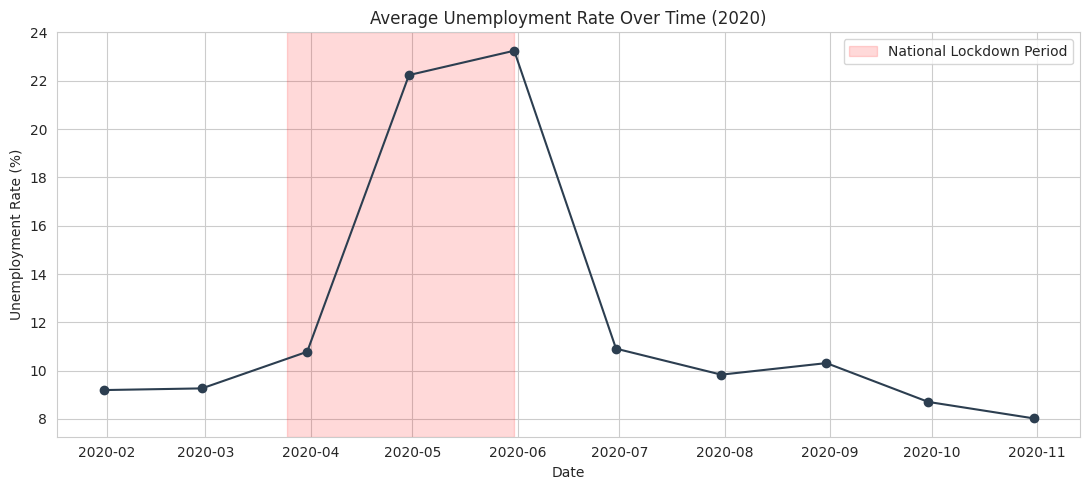

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

national_trend = df.groupby('Date')['Unemployment_Rate'].mean().reset_index()

plt.figure(figsize=(11, 5))
plt.plot(national_trend['Date'], national_trend['Unemployment_Rate'], marker='o', color='#2c3e50')
plt.axvspan(pd.Timestamp('2020-03-25'), pd.Timestamp('2020-05-31'), color='red', alpha=0.15, label='National Lockdown Period')
plt.title('Average Unemployment Rate Over Time (2020)')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.tight_layout()
plt.savefig('../images/unemployment_trend.png', dpi=150)
plt.show()

## 4. Covid-19 Impact: Pre vs Post Lockdown

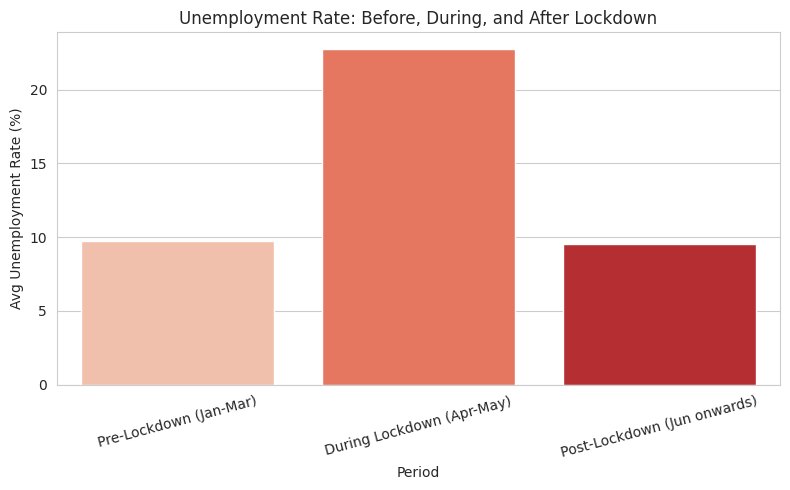

,Period,Avg Unemployment Rate (%)
0,Pre-Lockdown (Jan-Mar),9.761519
1,During Lockdown (Apr-May),22.749811
2,Post-Lockdown (Jun onwards),9.558222


In [6]:
pre_lockdown = df[df['Date'] < '2020-04-01']['Unemployment_Rate'].mean()
during_lockdown = df[(df['Date'] >= '2020-04-01') & (df['Date'] <= '2020-05-31')]['Unemployment_Rate'].mean()
post_lockdown = df[df['Date'] > '2020-05-31']['Unemployment_Rate'].mean()

comparison = pd.DataFrame({
    'Period': ['Pre-Lockdown (Jan-Mar)', 'During Lockdown (Apr-May)', 'Post-Lockdown (Jun onwards)'],
    'Avg Unemployment Rate (%)': [pre_lockdown, during_lockdown, post_lockdown]
})

plt.figure(figsize=(8, 5))
sns.barplot(data=comparison, x='Period', y='Avg Unemployment Rate (%)', hue='Period', palette='Reds', legend=False)
plt.title('Unemployment Rate: Before, During, and After Lockdown')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../images/covid_impact_comparison.png', dpi=150)
plt.show()

comparison

## 5. Regional Comparison

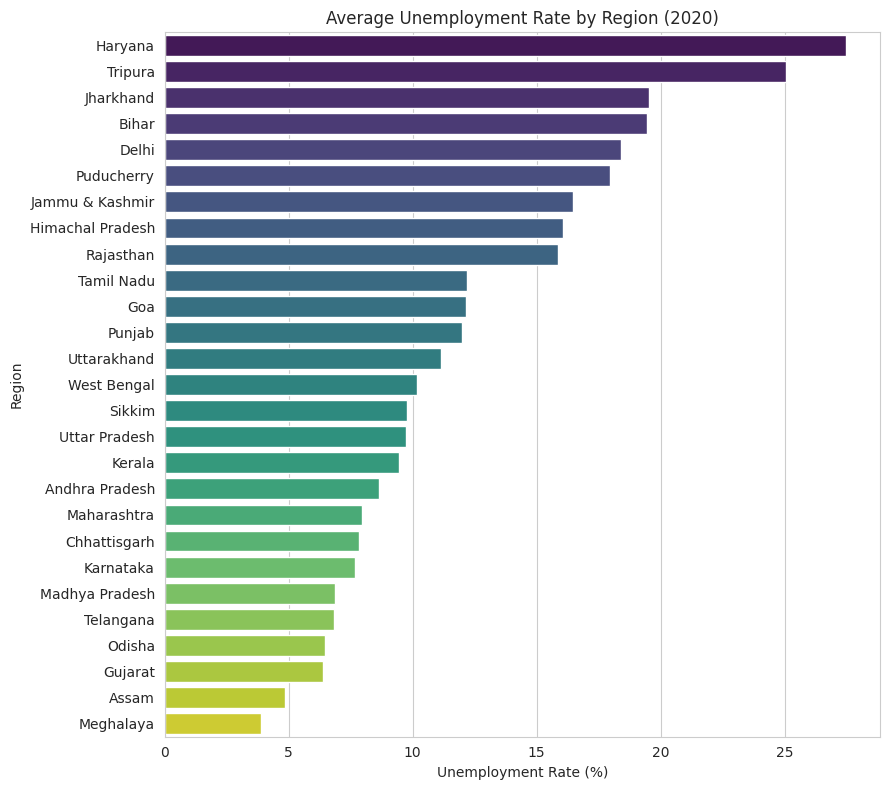

Highest unemployment: Haryana (27.48%)
Lowest unemployment: Meghalaya (3.87%)


In [7]:
regional_avg = df.groupby('Region')['Unemployment_Rate'].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 8))
sns.barplot(x=regional_avg.values, y=regional_avg.index, hue=regional_avg.index, palette='viridis', legend=False)
plt.title('Average Unemployment Rate by Region (2020)')
plt.xlabel('Unemployment Rate (%)')
plt.tight_layout()
plt.savefig('../images/regional_comparison.png', dpi=150)
plt.show()

print("Highest unemployment:", regional_avg.index[0], f"({regional_avg.iloc[0]:.2f}%)")
print("Lowest unemployment:", regional_avg.index[-1], f"({regional_avg.iloc[-1]:.2f}%)")

## 6. Labour Participation Rate vs Unemployment

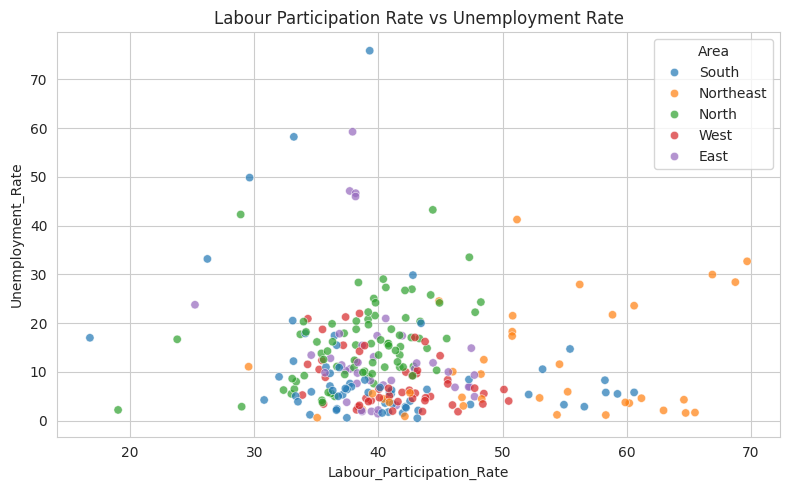

Correlation: -0.074


In [8]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Labour_Participation_Rate', y='Unemployment_Rate', hue='Area', alpha=0.7)
plt.title('Labour Participation Rate vs Unemployment Rate')
plt.tight_layout()
plt.savefig('../images/participation_vs_unemployment.png', dpi=150)
plt.show()

print("Correlation:", df['Labour_Participation_Rate'].corr(df['Unemployment_Rate']).round(3))

## 7. Urban vs Rural Comparison

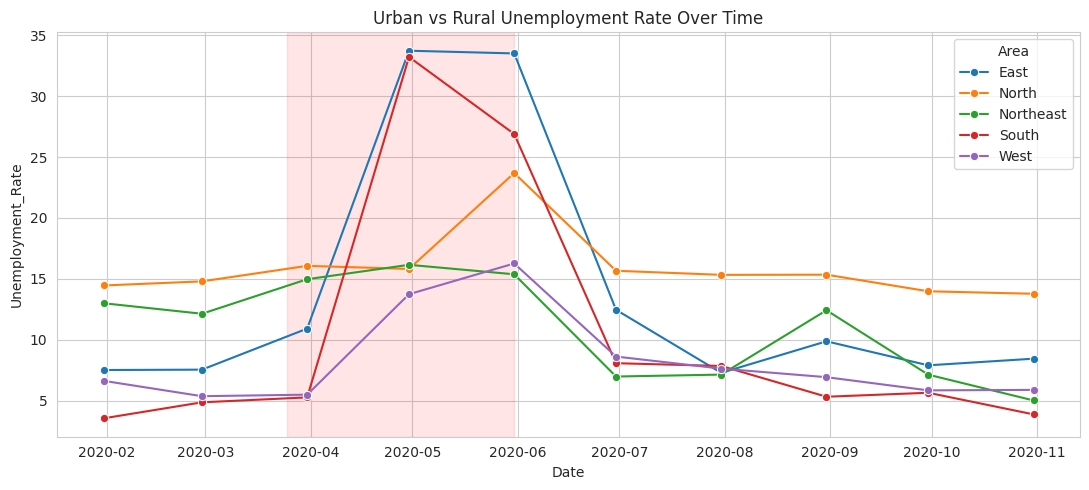

In [9]:
area_trend = df.groupby(['Date', 'Area'])['Unemployment_Rate'].mean().reset_index()

plt.figure(figsize=(11, 5))
sns.lineplot(data=area_trend, x='Date', y='Unemployment_Rate', hue='Area', marker='o')
plt.axvspan(pd.Timestamp('2020-03-25'), pd.Timestamp('2020-05-31'), color='red', alpha=0.1)
plt.title('Urban vs Rural Unemployment Rate Over Time')
plt.tight_layout()
plt.savefig('../images/urban_rural_comparison.png', dpi=150)
plt.show()

## 8. Key Insights & Conclusion

- National unemployment rate spiked sharply during the **April-May 2020 lockdown period**, rising from a pre-lockdown average to a much higher during-lockdown average (see comparison chart).
- The rate began recovering after May 2020 as restrictions eased, though it did not fully return to pre-lockdown levels by October 2020.
- Regional disparity is significant — some regions experienced far higher unemployment than others throughout the year, suggesting the economic impact of the lockdown was not evenly distributed.
- Urban and rural areas showed different patterns, with one area type generally experiencing sharper swings than the other during the lockdown period.
- **Policy implication:** These patterns suggest targeted economic relief during lockdown-style disruptions should account for regional and urban/rural disparities rather than applying a uniform national approach.

**Tools used:** Python, pandas, matplotlib, seaborn